# Pareto Sampling Report

This notebook reads one or more `points.csv` files produced by `src/sample_exp.py`, builds Pareto fronts for every sampled run, and compares selected experiments.

Expected `points.csv` columns:

- `circuit`
- `run_id`
- `size`
- `depth`

Rows with missing `run_id` are treated as the original circuit point and are used for normalization.

In [1]:
from __future__ import annotations

from itertools import product
from pathlib import Path
from statistics import fmean, pstdev

import pandas as pd

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 50)

## Inputs

Set `points_csv_paths` to the `points.csv` files you want to compare. By default, `run_name` is inferred from the parent experiment directory name.

In [2]:
# Fill this list with paths to points.csv files produced by src/sample_exp.py.
points_csv_paths = [
    # "../outputs/2026-05-26/12:06_tb_zhu_i10_79035/points.csv",
]

output_dir = Path('../outputs')
points_csv_paths = list(filter(lambda p: p.name == 'points.csv', output_dir.glob('**/*.csv')))
print(len(points_csv_paths))

# Optional friendly labels. If a path is missing here, its parent directory name is used.
run_name_overrides = {
    # "../outputs/2026-05-26/12:06_tb_zhu_i10_79035/points.csv": "gflownet_tb",
}
run_name_overrides = {str(p): '_'.join(p.parent.name.split('_')[1:-1]) for p in points_csv_paths}
print(run_name_overrides)

14
{'../outputs/2026-06-16/13:03:50_ppo_zhuDOP_c1355_88738/points.csv': 'ppo_zhuDOP_c1355', '../outputs/2026-06-16/14:23:49_ppo_zhuLinear_c1355_88739/points.csv': 'ppo_zhuLinear_c1355', '../outputs/2026-06-15/17:20:07_zhuLinear_apex1_88269/points.csv': 'zhuLinear_apex1', '../outputs/2026-06-15/14:53:09_zhuLinear_c1355_88269/points.csv': 'zhuLinear_c1355', '../outputs/2026-06-15/21:48:21_zhuLinear_dalu_88269/points.csv': 'zhuLinear_dalu', '../outputs/2026-06-15/15:25:22_zhuDOP_bc0_88268/points.csv': 'zhuDOP_bc0', '../outputs/2026-06-15/14:53:06_zhuDOP_c1355_88268/points.csv': 'zhuDOP_c1355', '../outputs/2026-06-15/17:13:50_zhuDOP_apex1_88268/points.csv': 'zhuDOP_apex1', '../outputs/2026-06-15/22:25:40_zhuDOP_k2_88268/points.csv': 'zhuDOP_k2', '../outputs/2026-06-15/21:04:52_zhuLinear_c5315_88269/points.csv': 'zhuLinear_c5315', '../outputs/2026-06-15/21:39:05_zhuDOP_dalu_88268/points.csv': 'zhuDOP_dalu', '../outputs/2026-06-15/20:54:41_zhuDOP_c5315_88268/points.csv': 'zhuDOP_c5315', '../

## Pareto Helpers

The notebook minimizes normalized `(size, depth)`, where the original circuit is `(1, 1)`. Hypervolume is the area dominated by the Pareto front and bounded by the original circuit reference point.

In [3]:
def weakly_dominates_min(a, b):
    """Return True when point a weakly dominates point b in minimization space."""
    return a[0] <= b[0] and a[1] <= b[1]


def strictly_dominates_min(a, b):
    return weakly_dominates_min(a, b) and (a[0] < b[0] or a[1] < b[1])


def pareto_front_min(points):
    """Deduplicated nondominated points for 2D minimization."""
    unique_points = sorted(set((float(x), float(y)) for x, y in points), key=lambda p: (p[0], p[1]))
    return [
        point
        for point in unique_points
        if not any(strictly_dominates_min(other, point) for other in unique_points)
    ]


def hypervolume_min_2d(points, reference=(1.0, 1.0)):
    """2D minimization hypervolume relative to the original circuit point."""
    front = pareto_front_min(points)
    clipped = sorted(
        {
            (max(0.0, min(reference[0], x)), max(0.0, min(reference[1], y)))
            for x, y in front
            if x < reference[0] and y < reference[1]
        },
        key=lambda p: p[0],
    )
    hv = 0.0
    for idx, (x, y) in enumerate(clipped):
        next_x = clipped[idx + 1][0] if idx + 1 < len(clipped) else reference[0]
        hv += max(0.0, next_x - x) * max(0.0, reference[1] - y)
    return float(hv)


def additive_epsilon_min(source_points, target_points):
    """Smallest eps such that source weakly epsilon-dominates target in minimization space."""
    source_front = pareto_front_min(source_points)
    target_front = pareto_front_min(target_points)
    if not target_front:
        return 0.0
    if not source_front:
        return float("inf")
    return float(
        max(
            min(max(source[0] - target[0], source[1] - target[1]) for source in source_front)
            for target in target_front
        )
    )


def dominance_ratio_min(source_points, target_points):
    """Fraction of target front points weakly dominated by the source front."""
    source_front = pareto_front_min(source_points)
    target_front = pareto_front_min(target_points)
    if not target_front:
        return 0.0
    dominated = sum(
        1
        for target in target_front
        if any(weakly_dominates_min(source, target) for source in source_front)
    )
    return float(dominated / len(target_front))


def summarize(values):
    values = [float(v) for v in values]
    if not values:
        return {"n": 0, "mean": None, "std": None, "stderr": None, "min": None, "max": None}
    std = pstdev(values) if len(values) > 1 else 0.0
    return {
        "n": len(values),
        "mean": fmean(values),
        "std": std,
        "stderr": std / (len(values) ** 0.5),
        "min": min(values),
        "max": max(values),
    }

## Load Points And Build Per-Run Metrics

`points_df` contains all normalized sampled points. `summary_df` is the requested dataframe with one row per `(run_name, run_id, circuit)`.

In [4]:
def resolve_path(path_like):
    path = Path(path_like).expanduser()
    if path.is_absolute():
        return path
    return (Path.cwd() / path).resolve()


def load_points_csv(path_like, run_name=None):
    path = resolve_path(path_like)
    df = pd.read_csv(path)
    required = {"circuit", "run_id", "size", "depth"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"{path} is missing required columns: {sorted(missing)}")

    df = df.copy()
    df["points_csv"] = str(path)
    df["run_name"] = run_name or path.parent.name
    df["run_id"] = pd.to_numeric(df["run_id"], errors="coerce").astype("Int64")
    df["size"] = pd.to_numeric(df["size"])
    df["depth"] = pd.to_numeric(df["depth"])
    return df


frames = []
for path_like in points_csv_paths:
    path_key = str(path_like)
    frames.append(load_points_csv(path_like, run_name=run_name_overrides.get(path_key)))

if not frames:
    raise ValueError("Fill points_csv_paths with at least one points.csv path, then rerun this cell.")

raw_points_df = pd.concat(frames, ignore_index=True)

initial_df = (
    raw_points_df[raw_points_df["run_id"].isna()]
    .drop_duplicates(subset=["run_name", "circuit"])
    [["run_name", "circuit", "size", "depth"]]
    .rename(columns={"size": "initial_size", "depth": "initial_depth"})
)

sample_df = raw_points_df[raw_points_df["run_id"].notna()].copy()
points_df = sample_df.merge(initial_df, on=["run_name", "circuit"], how="left", validate="many_to_one")
if points_df[["initial_size", "initial_depth"]].isna().any().any():
    missing = points_df[points_df[["initial_size", "initial_depth"]].isna().any(axis=1)][["run_name", "circuit"]].drop_duplicates()
    raise ValueError(f"Missing original-circuit rows for:\n{missing}")

points_df["normalized_size"] = points_df["size"] / points_df["initial_size"]
points_df["normalized_depth"] = points_df["depth"] / points_df["initial_depth"]
points_df["size_reduction"] = 1.0 - points_df["normalized_size"]
points_df["depth_reduction"] = 1.0 - points_df["normalized_depth"]
points_df['circuit'] = points_df['circuit'].map(lambda x: x.split('/')[-1].split('.')[0])

rows = []
fronts = {}
for (run_name, run_id, circuit), group in points_df.groupby(["run_name", "run_id", "circuit"], dropna=False):
    points = list(zip(group["normalized_size"], group["normalized_depth"]))
    front = pareto_front_min(points)
    fronts[(run_name, int(run_id), circuit)] = front
    rows.append(
        {
            "run_name": run_name,
            "run_id": int(run_id),
            "circuit": circuit,
            "hypervolume": hypervolume_min_2d(front),
            "number of nondominated points": len(front),
        }
    )

summary_df = pd.DataFrame(rows).sort_values(["circuit", "run_name", "run_id"]).reset_index(drop=True)
# summary_df['circuit'] = summary_df['circuit'].map(lambda x: x.split('/')[-1].split('.')[0])
# print((summary_df.loc[0, 'circuit']))
# summary_df.loc[summary_df['run_name'].str.startswith('ppo')]
print(summary_df['run_name'].unique())
summary_df

<StringArray>
[   'ppo_zhuDOP_c1355', 'ppo_zhuLinear_c1355',        'zhuDOP_c1355',
     'zhuLinear_c1355',        'zhuDOP_c5315',     'zhuLinear_c5315',
        'zhuDOP_apex1',     'zhuLinear_apex1',          'zhuDOP_bc0',
       'zhuLinear_bc0',         'zhuDOP_dalu',      'zhuLinear_dalu',
           'zhuDOP_k2',        'zhuLinear_k2']
Length: 14, dtype: str


,run_name,run_id,circuit,hypervolume,number of nondominated points
0,ppo_zhuDOP_c1355,0,C1355,0.081044,1
1,ppo_zhuDOP_c1355,1,C1355,0.081044,1
2,ppo_zhuDOP_c1355,2,C1355,0.081044,1
3,ppo_zhuDOP_c1355,3,C1355,0.081044,1
4,ppo_zhuDOP_c1355,4,C1355,0.081044,1
5,ppo_zhuDOP_c1355,5,C1355,0.078984,1
6,ppo_zhuDOP_c1355,6,C1355,0.078984,1
7,ppo_zhuDOP_c1355,7,C1355,0.078984,1
8,ppo_zhuDOP_c1355,8,C1355,0.081044,1
9,ppo_zhuDOP_c1355,9,C1355,0.081044,1


## Average Metrics Across Runs

This aggregates the per-run dataframe by experiment and circuit, which is useful for RL/GFlowNet comparisons over multiple trained policies.

In [5]:
aggregate_summary_df = (
    summary_df.groupby(["run_name", "circuit"])
    .agg(
        n_runs=("run_id", "nunique"),
        hypervolume_mean=("hypervolume", "mean"),
        hypervolume_std=("hypervolume", "std"),
        hypervolume_min=("hypervolume", "min"),
        hypervolume_max=("hypervolume", "max"),
        nondominated_mean=("number of nondominated points", "mean"),
        nondominated_std=("number of nondominated points", "std"),
        nondominated_min=("number of nondominated points", "min"),
        nondominated_max=("number of nondominated points", "max"),
    )
    .reset_index()
)
aggregate_summary_df["hypervolume_stderr"] = aggregate_summary_df["hypervolume_std"] / aggregate_summary_df["n_runs"].pow(0.5)
aggregate_summary_df["nondominated_stderr"] = aggregate_summary_df["nondominated_std"] / aggregate_summary_df["n_runs"].pow(0.5)
aggregate_summary_df

,run_name,circuit,n_runs,hypervolume_mean,hypervolume_std,hypervolume_min,hypervolume_max,nondominated_mean,nondominated_std,nondominated_min,nondominated_max,hypervolume_stderr,nondominated_stderr
0,ppo_zhuDOP_c1355,C1355,10,0.080426,0.000995,0.078984,0.081044,1.0,0.000000,1,1,0.000315,0.000000
1,ppo_zhuLinear_c1355,C1355,10,0.078846,0.002974,0.070818,0.081044,1.1,0.316228,1,2,0.000940,0.100000
2,zhuDOP_apex1,apex1,10,0.110811,0.002304,0.107275,0.114334,2.8,1.229273,1,5,0.000729,0.388730
3,zhuDOP_bc0,bc0,10,0.215110,0.008780,0.204186,0.223983,2.8,1.135292,2,5,0.002776,0.359011
4,zhuDOP_c1355,C1355,10,0.075137,0.006192,0.063034,0.080891,1.6,0.516398,1,2,0.001958,0.163299
5,zhuDOP_c5315,C5315,10,0.086529,0.005687,0.077330,0.092766,3.0,0.816497,2,4,0.001798,0.258199
6,zhuDOP_dalu,dalu,10,0.030055,0.003886,0.021569,0.036095,1.9,0.875595,1,3,0.001229,0.276887
7,zhuDOP_k2,k2,10,0.184726,0.010329,0.170018,0.199025,2.8,0.918937,2,4,0.003266,0.290593
8,zhuLinear_apex1,apex1,10,0.109761,0.003490,0.101207,0.112743,3.2,0.788811,2,4,0.001104,0.249444
9,zhuLinear_bc0,bc0,10,0.218923,0.006917,0.205584,0.225199,2.5,1.080123,1,4,0.002187,0.341565


## Pairwise Experiment Comparison

Choose a circuit and a set of experiments. Pairwise values are computed over all run pairs between two experiments and then summarized.

In [6]:
# Choose the comparison target.
selected_circuit = points_df["circuit"].unique()[0]
# selected_circuit = 'bc0'
_selected_experiments = points_df.loc[points_df["circuit"] == selected_circuit]
selected_experiments = sorted(_selected_experiments["run_name"].unique())


print("Selected circuit:", selected_circuit)
print("Selected experiments:", selected_experiments)

circ_sum_df = summary_df.loc[
    summary_df["circuit"] == selected_circuit,
    ["run_name", "hypervolume", "number of nondominated points"]
].groupby("run_name").agg("mean")
circ_sum_df

Selected circuit: C1355
Selected experiments: ['ppo_zhuDOP_c1355', 'ppo_zhuLinear_c1355', 'zhuDOP_c1355', 'zhuLinear_c1355']


,hypervolume,number of nondominated points
run_name,,
ppo_zhuDOP_c1355,0.080426,1.0
ppo_zhuLinear_c1355,0.078846,1.1
zhuDOP_c1355,0.075137,1.6
zhuLinear_c1355,0.074252,1.6


In [7]:
def run_fronts_for(run_name, circuit):
    run_rows = summary_df[(summary_df["run_name"] == run_name) & (summary_df["circuit"] == circuit)]
    return {
        int(row.run_id): fronts[(run_name, int(row.run_id), circuit)]
        for row in run_rows.itertuples(index=False)
    }


pairwise_rows = []
for source_name, target_name in product(selected_experiments, repeat=2):
    if source_name == target_name:
        continue
    source_fronts = run_fronts_for(source_name, selected_circuit)
    target_fronts = run_fronts_for(target_name, selected_circuit)

    eps_values = []
    dominance_values = []
    for source_run_id, source_front in source_fronts.items():
        for target_run_id, target_front in target_fronts.items():
            eps_values.append(additive_epsilon_min(source_front, target_front))
            dominance_values.append(dominance_ratio_min(source_front, target_front))

    eps_summary = summarize(eps_values)
    dominance_summary = summarize(dominance_values)
    pairwise_rows.append(
        {
            "source_run_name": source_name,
            "target_run_name": target_name,
            "circuit": selected_circuit,
            "n_run_pairs": eps_summary["n"],
            "additive_epsilon_mean": eps_summary["mean"],
            "additive_epsilon_std": eps_summary["std"],
            "additive_epsilon_stderr": eps_summary["stderr"],
            "additive_epsilon_min": eps_summary["min"],
            "additive_epsilon_max": eps_summary["max"],
            "dominance_ratio_mean": dominance_summary["mean"],
            "dominance_ratio_std": dominance_summary["std"],
            "dominance_ratio_stderr": dominance_summary["stderr"],
            "dominance_ratio_min": dominance_summary["min"],
            "dominance_ratio_max": dominance_summary["max"],
        }
    )

pairwise_df = pd.DataFrame(pairwise_rows)
pairwise_df

,source_run_name,target_run_name,circuit,n_run_pairs,additive_epsilon_mean,additive_epsilon_std,additive_epsilon_stderr,additive_epsilon_min,additive_epsilon_max,dominance_ratio_mean,dominance_ratio_std,dominance_ratio_stderr,dominance_ratio_min,dominance_ratio_max
0,ppo_zhuDOP_c1355,ppo_zhuLinear_c1355,C1355,100,0.000377,0.002094,0.000209,-0.003968,0.005952,0.865000,0.330568,0.033057,0.0,1.0
1,ppo_zhuDOP_c1355,zhuDOP_c1355,C1355,100,0.001012,0.002669,0.000267,-0.001984,0.005952,0.700000,0.458258,0.045826,0.0,1.0
2,ppo_zhuDOP_c1355,zhuLinear_c1355,C1355,100,0.000734,0.003082,0.000308,-0.003968,0.005952,0.700000,0.458258,0.045826,0.0,1.0
3,ppo_zhuLinear_c1355,ppo_zhuDOP_c1355,C1355,100,0.006346,0.011070,0.001107,0.000000,0.038462,0.480000,0.499600,0.049960,0.0,1.0
4,ppo_zhuLinear_c1355,zhuDOP_c1355,C1355,100,0.004562,0.008193,0.000819,-0.001984,0.038462,0.320000,0.455631,0.045563,0.0,1.0
5,ppo_zhuLinear_c1355,zhuLinear_c1355,C1355,100,0.003694,0.006789,0.000679,-0.003968,0.038462,0.340000,0.473709,0.047371,0.0,1.0
6,zhuDOP_c1355,ppo_zhuDOP_c1355,C1355,100,0.024466,0.024297,0.002430,0.000000,0.076923,0.150000,0.357071,0.035707,0.0,1.0
7,zhuDOP_c1355,ppo_zhuLinear_c1355,C1355,100,0.021749,0.024682,0.002468,0.000000,0.076923,0.410000,0.481560,0.048156,0.0,1.0
8,zhuDOP_c1355,zhuLinear_c1355,C1355,100,0.010687,0.018642,0.001864,0.000000,0.076923,0.493333,0.435201,0.043520,0.0,1.0
9,zhuLinear_c1355,ppo_zhuDOP_c1355,C1355,100,0.027618,0.016591,0.001659,0.000000,0.038462,0.090000,0.286182,0.028618,0.0,1.0


## Print Selected Pareto Fronts

This prints a Pareto front for each selected experiment on the chosen circuit. The front is pooled across selected runs for that experiment, then filtered again for nondominated normalized `(size, depth)` points.

In [8]:
# Choose which runs to include in the printed front. None means all runs for each experiment.
selected_run_ids = None  # example: [0, 1, 2]

front_rows = []
for run_name in selected_experiments:
    subset = points_df[(points_df["run_name"] == run_name) & (points_df["circuit"] == selected_circuit)]
    if selected_run_ids is not None:
        subset = subset[subset["run_id"].isin(selected_run_ids)]

    pooled_points = list(zip(subset["normalized_size"], subset["normalized_depth"]))
    pooled_front = pareto_front_min(pooled_points)
    for normalized_size, normalized_depth in pooled_front:
        matching = subset[
            (subset["normalized_size"] == normalized_size)
            & (subset["normalized_depth"] == normalized_depth)
        ].iloc[0]
        front_rows.append(
            {
                "run_name": run_name,
                "circuit": selected_circuit,
                "normalized_size": normalized_size,
                "normalized_depth": normalized_depth,
                "size_reduction": 1.0 - normalized_size,
                "depth_reduction": 1.0 - normalized_depth,
                "size": int(matching["size"]),
                "depth": int(matching["depth"]),
            }
        )

selected_front_df = pd.DataFrame(front_rows).sort_values(
    ["run_name", "normalized_size", "normalized_depth"]
).reset_index(drop=True)

print(f"Pareto fronts for circuit: {selected_circuit}")
print(f"Experiments: {selected_experiments}")
print(selected_front_df.to_string(index=False))
selected_front_df

Pareto fronts for circuit: C1355
Experiments: ['ppo_zhuDOP_c1355', 'ppo_zhuLinear_c1355', 'zhuDOP_c1355', 'zhuLinear_c1355']
           run_name circuit  normalized_size  normalized_depth  size_reduction  depth_reduction  size  depth
   ppo_zhuDOP_c1355   C1355         0.765873          0.653846        0.234127         0.346154   386     17
ppo_zhuLinear_c1355   C1355         0.765873          0.653846        0.234127         0.346154   386     17
       zhuDOP_c1355   C1355         0.765873          0.692308        0.234127         0.307692   386     18
       zhuDOP_c1355   C1355         0.769841          0.653846        0.230159         0.346154   388     17
    zhuLinear_c1355   C1355         0.765873          0.692308        0.234127         0.307692   386     18
    zhuLinear_c1355   C1355         0.767857          0.653846        0.232143         0.346154   387     17


,run_name,circuit,normalized_size,normalized_depth,size_reduction,depth_reduction,size,depth
0,ppo_zhuDOP_c1355,C1355,0.765873,0.653846,0.234127,0.346154,386,17
1,ppo_zhuLinear_c1355,C1355,0.765873,0.653846,0.234127,0.346154,386,17
2,zhuDOP_c1355,C1355,0.765873,0.692308,0.234127,0.307692,386,18
3,zhuDOP_c1355,C1355,0.769841,0.653846,0.230159,0.346154,388,17
4,zhuLinear_c1355,C1355,0.765873,0.692308,0.234127,0.307692,386,18
5,zhuLinear_c1355,C1355,0.767857,0.653846,0.232143,0.346154,387,17


## Plot Selected Pareto Fronts

This plots the pooled Pareto front for each selected experiment on the selected circuit in normalized minimization space. Lower-left is better.

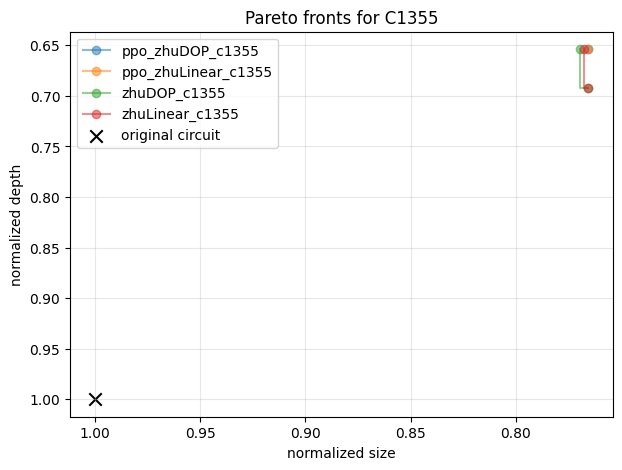

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 5))

for run_name in selected_experiments:
    front = selected_front_df[selected_front_df["run_name"] == run_name].sort_values(
        ["normalized_size", "normalized_depth"]
    )
    if front.empty:
        continue
    ax.step(
        front["normalized_size"],
        front["normalized_depth"],
        where="post",
        marker="o",
        alpha=0.5,
        label=run_name,
    )

ax.scatter([1.0], [1.0], marker="x", s=80, color="black", label="original circuit")
ax.set_xlabel("normalized size")
ax.set_ylabel("normalized depth")
ax.set_title(f"Pareto fronts for {Path(selected_circuit).name}")
ax.grid(True, alpha=0.3)
ax.legend()
ax.invert_xaxis()
ax.invert_yaxis()
plt.show()